In [1]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint
from matplotlib.ticker import FormatStrFormatter

In [2]:
strict_pairs_baseline = pd.read_csv('synthetic/baseline/strict_preference_pairs.csv')
equal_pairs_baseline = pd.read_csv('synthetic/baseline/equal_pairs.csv')

In [4]:
strict_pairs_baseline_noabstain = pd.read_csv('synthetic/baseline_noabstain/strict_preference_pairs.csv')
equal_pairs_baseline_noabstain = pd.read_csv('synthetic/baseline_noabstain/equal_pairs.csv')

In [3]:
strict_pairs_noncs = pd.read_csv('noncs/baseline/strict_preference_pairs.csv')
equal_pairs_noncs = pd.read_csv('noncs/baseline/equal_pairs.csv')

strict_pairs_noncs_noabstain = pd.read_csv('noncs/baseline_noabstain/strict_preference_pairs.csv')
equal_pairs_noncs_noabstain = pd.read_csv('noncs/baseline_noabstain/equal_pairs.csv')

# Analysis of Unequal Pairs: Criterion Validity, Error Types, Over-Assessment

## Criterion Validity and Error Breakdown Disaggregated by Model, k

In [5]:
strict_pairs_baseline['incorrect'] = 1 - strict_pairs_baseline['is_correct'] - strict_pairs_baseline['abstained']
strict_pairs_baseline['proportion_abstention'] = strict_pairs_baseline['abstained'] / (strict_pairs_baseline['abstained'] + strict_pairs_baseline['incorrect'])

cv_by_demo_baseline = strict_pairs_baseline.groupby(['model_id', 'k']).agg({'is_correct': 'mean', 'abstained': 'mean', 'incorrect': 'mean', 'proportion_abstention': 'mean'})

for idx, row in cv_by_demo_baseline.iterrows():
    print(row)


is_correct               0.903748
abstained                0.093697
incorrect                0.002555
proportion_abstention    0.973451
Name: (claude-sonnet-4, 1), dtype: float64
is_correct               0.980769
abstained                0.016194
incorrect                0.003036
proportion_abstention    0.842105
Name: (claude-sonnet-4, 2), dtype: float64
is_correct               0.996583
abstained                0.001139
incorrect                0.002278
proportion_abstention    0.333333
Name: (claude-sonnet-4, 3), dtype: float64
is_correct               0.698344
abstained                0.292938
incorrect                0.008718
proportion_abstention    0.971098
Name: (deepseek-chat-v3.1, 1), dtype: float64
is_correct               0.887958
abstained                0.100524
incorrect                0.011518
proportion_abstention    0.897196
Name: (deepseek-chat-v3.1, 2), dtype: float64
is_correct               0.929825
abstained                0.058480
incorrect                0.0116

In [6]:
# models_of_interest = ['gpt-5', 'claude-sonnet-4', 'gemini-2.5-pro', 'deepseek-chat-v3.1', 'llama-3.3-70b-instruct']

# df = strict_pairs_baseline[strict_pairs_baseline['model_id'].isin(models_of_interest)]

cv_by_demo_baseline_plot = strict_pairs_baseline.groupby(['model_id', 'k']).agg({'is_correct': 'mean', 'abstained': 'mean', 'incorrect': 'mean', 'proportion_abstention': 'mean'})

cv_by_demo_baseline_plot

is_correct  abstained  incorrect  \
model_id               k                                     
claude-sonnet-4        1    0.903748   0.093697   0.002555   
                       2    0.980769   0.016194   0.003036   
                       3    0.996583   0.001139   0.002278   
deepseek-chat-v3.1     1    0.698344   0.292938   0.008718   
                       2    0.887958   0.100524   0.011518   
                       3    0.929825   0.058480   0.011696   
gemini-2.0-flash-001   1    0.784490   0.189388   0.026122   
                       2    0.931001   0.053450   0.015549   
                       3    0.965812   0.022436   0.011752   
gemini-2.5-pro         1    0.856263   0.140657   0.003080   
                       2    0.953216   0.042105   0.004678   
                       3    0.982597   0.010710   0.006693   
gemma-3-12b-it         1    0.777599   0.201450   0.020951   
                       2    0.950962   0.041346   0.007692   
                       3    0.976420   0.015005   0.008574   
gpt-4o-mini            1    0.541396   0.442370   0.016234   
                       2    0.809293   0.169409   0.021297   
                       3    0.913866   0.067227   0.018908   
gpt-5                  1    0.870769   0.124103   0.005128   
                       2    0.961143   0.030857   0.008000   
                       3    0.985353   0.007989   0.006658   
llama-3.1-8b-instruct  1    0.652216   0.144509   0.203276   
                       2    0.750294   0.076561   0.173145   
                       3    0.759843   0.081365   0.158793   
llama-3.3-70b-instruct 1    0.469388   0.509276   0.021336   
                       2    0.713089   0.271204   0.015707   
                       3    0.814994   0.157195   0.027811   

                          proportion_abstention  
model_id               k                         
claude-sonnet-4        1               0.973451  
                       2               0.842105  
                       3               0.333333  
deepseek-chat-v3.1     1               0.971098  
                       2               0.897196  
                       3               0.833333  
gemini-2.0-flash-001   1               0.878788  
                       2               0.774648  
                       3               0.656250  
gemini-2.5-pro         1               0.978571  
                       2               0.900000  
                       3               0.615385  
gemma-3-12b-it         1               0.905797  
                       2               0.843137  
                       3               0.636364  
gpt-4o-mini            1               0.964602  
                       2               0.888325  
                       3               0.780488  
gpt-5                  1               0.960317  
                       2               0.794118  
                       3               0.545455  
llama-3.1-8b-instruct  1               0.415512  
                       2               0.306604  
                       3               0.338798  
llama-3.3-70b-instruct 1               0.959790  
                       2               0.945255  
                       3               0.849673

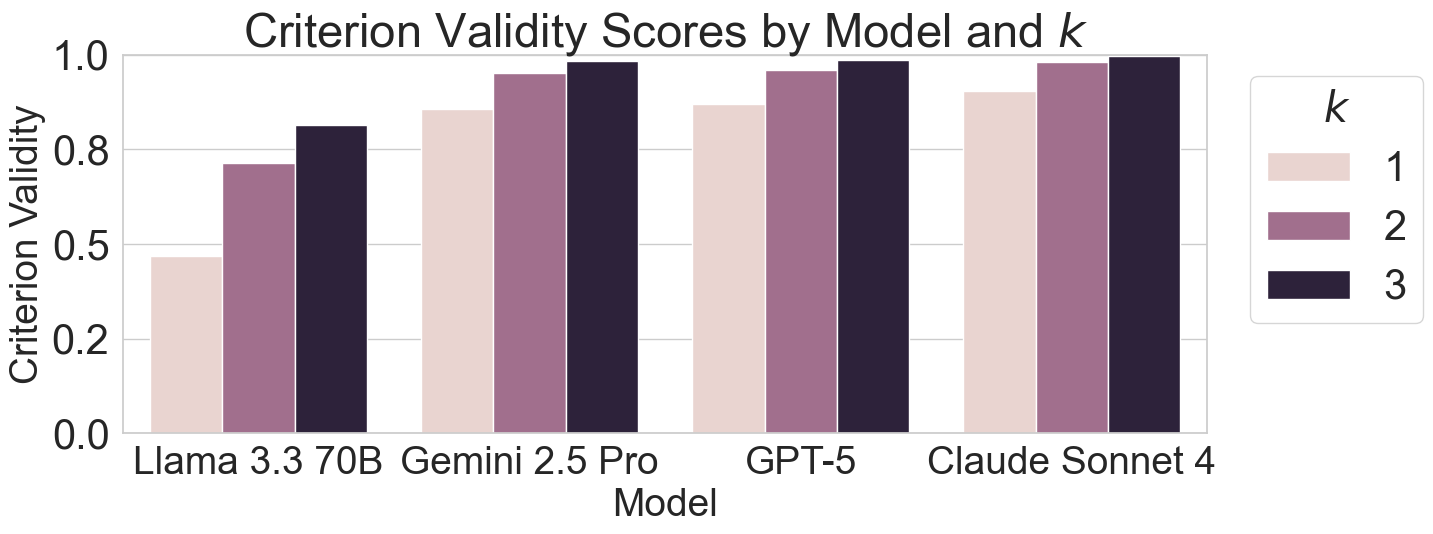

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

df = cv_by_demo_baseline_plot.reset_index()

short_models = {
    'gpt-5': 'GPT-5',
    'claude-sonnet-4': 'Claude Sonnet 4',
    'gemini-2.5-pro': 'Gemini 2.5 Pro',
    'deepseek-chat-v3.1': 'DeepSeek 3.1',
    'llama-3.3-70b-instruct': 'Llama 3.3 70B',
    'gemma-3-12b-it': 'Gemma 3 12B',
    'gemini-2.0-flash-001': 'Gemini 2.0 Flash',
    'llama-3.1-8b-instruct': 'Llama 3.1 8B',
    'gpt-4o-mini': 'GPT-4o Mini'
}

df['model_short'] = df['model_id'].map(short_models)


model_order = models_of_choice
df = df[df['model_short'].isin(models_of_choice)]

# 2. Configure the plot size and style
plt.figure(figsize=(14.5, 5.5))
sns.set_theme(style="whitegrid")

# 3. Create the grouped bar chart
# x = the groups (Models), hue = the bars within groups (k)
ax = sns.barplot(
    data=df,
    x='model_short',
    y='is_correct',
    hue='k',
    order=model_order,  # Enforce the specific order of models
)

ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# 4. Formatting
plt.title('Criterion Validity Scores by Model and $k$', fontsize=34)
plt.ylabel('Criterion Validity', fontsize=28)
plt.xlabel('Model', fontsize=28)
plt.ylim(0, 1.0) # Assuming score is 0-1 range; adjust if needed
plt.legend(title='$k$', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=30, title_fontsize=30)

ax.tick_params(axis='y', labelsize=30)
ax.tick_params(axis='x', labelsize=28)


plt.tight_layout()
plt.show()

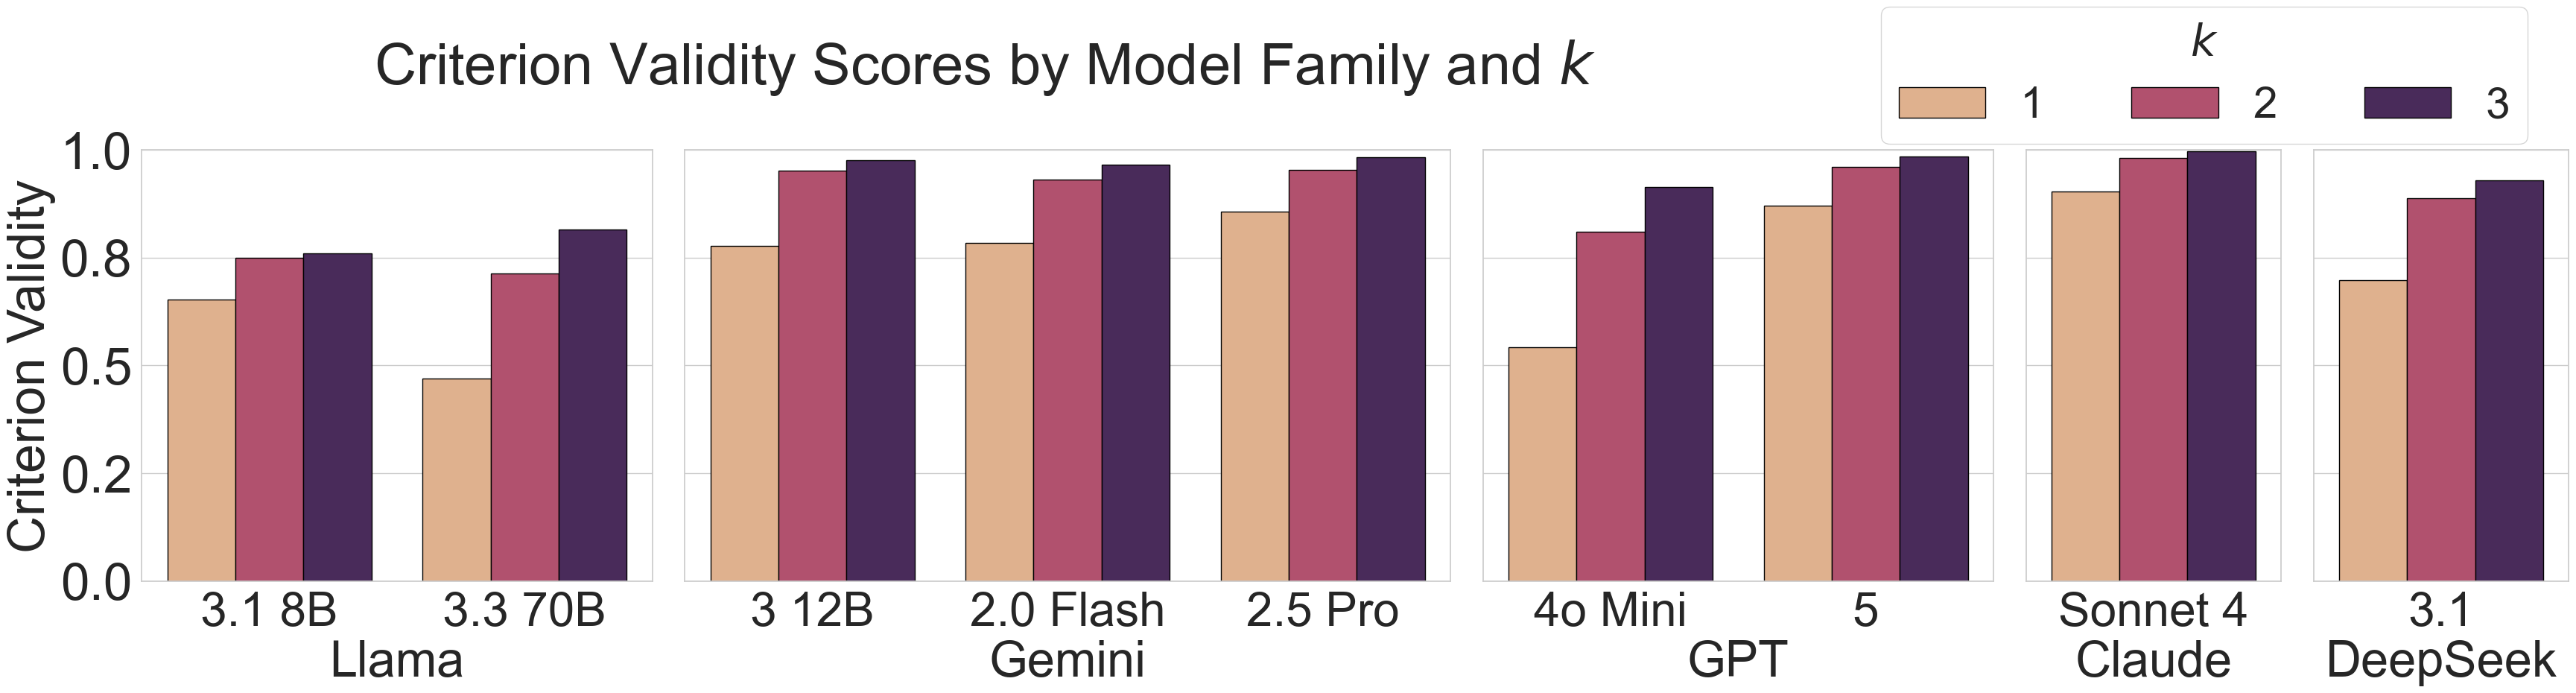

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# --- 1. Data Processing ---
df = cv_by_demo_baseline_plot.reset_index().copy()

short_models = {
    'gpt-5': 'GPT-5',
    'claude-sonnet-4': 'Claude Sonnet 4',
    'gemini-2.5-pro': 'Gem. 2.5 Pro',
    'deepseek-chat-v3.1': 'DeepSeek 3.1',
    'llama-3.3-70b-instruct': 'Llama 3.3 70B',
    'gemma-3-12b-it': 'Gem. 3 12B',
    'gemini-2.0-flash-001': 'Gem. 2.0 Flash',
    'llama-3.1-8b-instruct': 'Llama 3.1 8B',
    'gpt-4o-mini': 'GPT-4o Mini'
}
df['model_short'] = df['model_id'].map(short_models)

# Define Model Families
df['family'] = 'Other'
df.loc[df['model_short'].str.contains('Gem\.|Gemini|Gemma', na=False), 'family'] = 'Gemini'
df.loc[df['model_short'].str.contains('Llama', na=False), 'family'] = 'Llama'
df.loc[df['model_short'].str.contains('GPT', na=False), 'family'] = 'GPT'
df.loc[df['model_short'].str.contains('Claude', na=False), 'family'] = 'Claude'
df.loc[df['model_short'].str.contains('DeepSeek', na=False), 'family'] = 'DeepSeek'

# Extract versions for X-axis labels
def get_version(name):
    return (name.replace('Llama ', '')
                .replace('Gem. ', '')
                .replace('GPT-', '')
                .replace('Claude ', '')
                .replace('DeepSeek ', ''))

df['version'] = df['model_short'].apply(get_version)

# Ordering Setup
families = ['Llama', 'Gemini', 'GPT', 'Claude', 'DeepSeek']
version_order = {
    'Llama': ['3.1 8B', '3.3 70B'],
    'Gemini': ['3 12B', '2.0 Flash', '2.5 Pro'],
    'GPT': ['4o Mini', '5'],
    'Claude': ['Sonnet 4'],
    'DeepSeek': ['3.1']
}

# Aggregate data (assuming 'is_correct' is the score column)
df_plot = (df.groupby(['family', 'version', 'k'])['is_correct']
           .mean()
           .reset_index(name='val'))

# --- 2. Hierarchical Plotting ---
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 5, figsize=(35, 10), sharey=True, 
                         gridspec_kw={'width_ratios': [2, 3, 2, 1, 1]})

k_values = sorted(df_plot['k'].unique())
all_handles = []
all_labels = []

for i, family in enumerate(families):
    ax = axes[i]
    family_data = df_plot[df_plot['family'] == family].copy()
    order = version_order[family]
    
    sns.barplot(
        data=family_data, 
        x='version', 
        y='val', 
        hue='k', 
        hue_order=k_values,
        order=order,
        palette='flare', 
        ax=ax, 
        edgecolor='black'
    )
    
    # Store legend handles from the first valid subplot
    h, l = ax.get_legend_handles_labels()
    if h and not all_handles:
        all_handles, all_labels = h, l
        
    ax.set_xlabel("")
    ax.set_ylabel("Criterion Validity" if i == 0 else "", fontsize=50)
    ax.tick_params(axis='x', labelsize=46)
    ax.tick_params(axis='y', labelsize=50)
    ax.set_ylim(0, 1)
    
    # Family label at the bottom
    ax.text(0.5, -0.22, family, fontsize=48, ha='center', transform=ax.transAxes)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Remove individual subplot legends
    leg = ax.get_legend()
    if leg:
        leg.remove()

# Global Legend
if all_handles:
    fig.legend(all_handles, all_labels, title="$k$", title_fontsize=42, fontsize=42, 
               loc='upper right', bbox_to_anchor=(0.98, 1), ncol=len(k_values))

fig.suptitle("Criterion Validity Scores by Model Family and $k$", 
             fontsize=56, y=0.93, x=0.38)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [12]:
strict_pairs_noncs['incorrect'] = 1 - strict_pairs_noncs['is_correct'] - strict_pairs_noncs['abstained']
strict_pairs_noncs['proportion_abstention'] = strict_pairs_noncs['abstained'] / (strict_pairs_noncs['abstained'] + strict_pairs_noncs['incorrect'])

cv_by_demo_noncs = strict_pairs_noncs.groupby(['model_id', 'k']).agg({'is_correct': 'mean', 'abstained': 'mean', 'incorrect': 'mean', 'proportion_abstention': 'mean'})

cv_by_demo_noncs

is_correct  abstained  incorrect  \
model_id               k                                     
claude-sonnet-4        1    0.887755   0.081633   0.030612   
                       2    0.926829   0.060976   0.012195   
                       3    0.934211   0.026316   0.039474   
deepseek-chat-v3.1     1    0.633333   0.344444   0.022222   
                       2    0.864865   0.121622   0.013514   
                       3    0.941176   0.044118   0.014706   
gemini-2.0-flash-001   1    0.777778   0.166667   0.055556   
                       2    0.932432   0.067568   0.000000   
                       3    1.000000   0.000000   0.000000   
gemini-2.5-pro         1    0.693878   0.285714   0.020408   
                       2    0.890244   0.109756   0.000000   
                       3    0.960526   0.039474   0.000000   
gemma-3-12b-it         1    0.697674   0.290698   0.011628   
                       2    0.885714   0.085714   0.028571   
                       3    0.968750   0.031250   0.000000   
gpt-4o-mini            1    0.563830   0.414894   0.021277   
                       2    0.730769   0.269231   0.000000   
                       3    0.875000   0.125000   0.000000   
gpt-5                  1    0.739130   0.228261   0.032609   
                       2    0.935897   0.051282   0.012821   
                       3    0.944444   0.041667   0.013889   
llama-3.1-8b-instruct  1    0.691489   0.202128   0.106383   
                       2    0.679487   0.179487   0.141026   
                       3    0.708333   0.166667   0.125000   
llama-3.3-70b-instruct 1    0.340426   0.648936   0.010638   
                       2    0.564103   0.423077   0.012821   
                       3    0.694444   0.305556   0.000000   

                          proportion_abstention  
model_id               k                         
claude-sonnet-4        1               0.727273  
                       2               0.833333  
                       3               0.400000  
deepseek-chat-v3.1     1               0.939394  
                       2               0.900000  
                       3               0.750000  
gemini-2.0-flash-001   1               0.750000  
                       2               1.000000  
                       3                    NaN  
gemini-2.5-pro         1               0.933333  
                       2               1.000000  
                       3               1.000000  
gemma-3-12b-it         1               0.961538  
                       2               0.750000  
                       3               1.000000  
gpt-4o-mini            1               0.951220  
                       2               1.000000  
                       3               1.000000  
gpt-5                  1               0.875000  
                       2               0.800000  
                       3               0.750000  
llama-3.1-8b-instruct  1               0.655172  
                       2               0.560000  
                       3               0.571429  
llama-3.3-70b-instruct 1               0.983871  
                       2               0.970588  
                       3               1.000000

In [20]:
df['model_id'].unique()

array(['claude-sonnet-4', 'deepseek-chat-v3.1', 'gemini-2.0-flash-001',
       'gemini-2.5-pro', 'gemma-3-12b-it', 'gpt-4o-mini', 'gpt-5',
       'llama-3.1-8b-instruct', 'llama-3.3-70b-instruct'], dtype=object)

Index(['model_id', 'k', 'job_title', 'is_correct', 'abstained', 'incorrect',
       'proportion_abstention'],
      dtype='object')


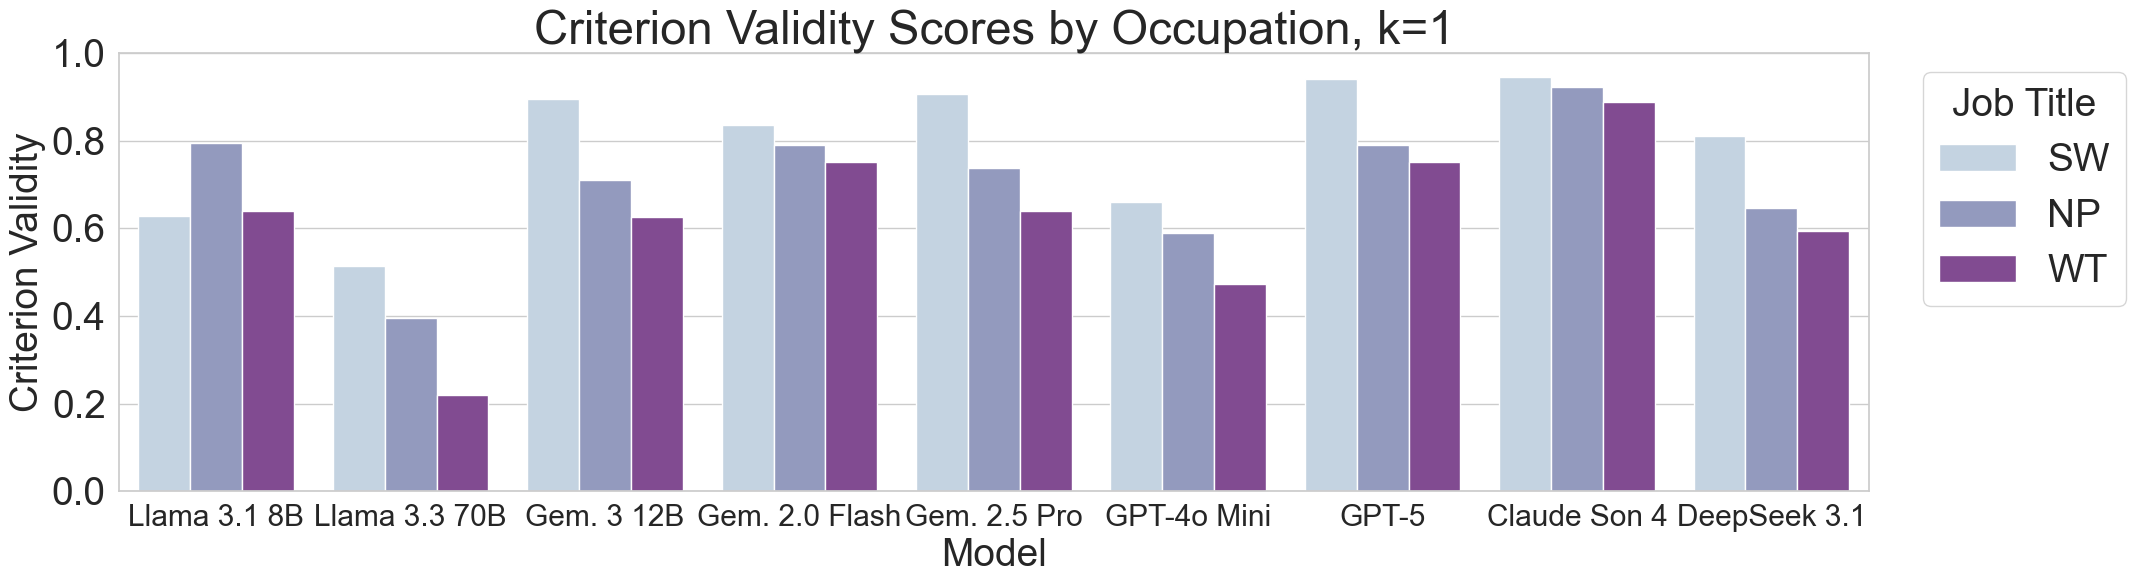

In [215]:
df = strict_pairs_noncs[strict_pairs_noncs['job_title'] == 'Nurse Practitioner']
cv_np = df.groupby(['model_id', 'k', 'job_title']).agg({'is_correct': 'mean', 'abstained': 'mean', 'incorrect': 'mean', 'proportion_abstention': 'mean'})

df = strict_pairs_baseline[strict_pairs_baseline['job_title'] == 'Software Engineer']
cv_swe = df.groupby(['model_id', 'k', 'job_title']).agg({'is_correct': 'mean', 'abstained': 'mean', 'incorrect': 'mean', 'proportion_abstention': 'mean'})

df = strict_pairs_noncs[strict_pairs_noncs['job_title'] == 'Wind Turbine Technician']
cv_wt = df.groupby(['model_id', 'k', 'job_title']).agg({'is_correct': 'mean', 'abstained': 'mean', 'incorrect': 'mean', 'proportion_abstention': 'mean'})

# merge, cv_np, cv_swe, cv_wt
df = pd.concat([cv_np, cv_swe, cv_wt]).reset_index()

print(df.columns)

# Filter for k = 1 and only the specific occupations
target_occupations = ['Software Engineer', 'Nurse Practitioner', 'Wind Turbine Technician']
df = df[(df['k'] == 1) & (df['job_title'].isin(target_occupations))]


# Mapping for models
short_models = {
    'gpt-5': 'GPT-5',
    'claude-sonnet-4': 'Claude Son 4',
    'gemini-2.5-pro': 'Gem. 2.5 Pro',
    'deepseek-chat-v3.1': 'DeepSeek 3.1',
    'llama-3.3-70b-instruct': 'Llama 3.3 70B',
    'gemma-3-12b-it': 'Gem. 3 12B',
    'gemini-2.0-flash-001': 'Gem. 2.0 Flash',
    'llama-3.1-8b-instruct': 'Llama 3.1 8B',
    'gpt-4o-mini': 'GPT-4o Mini'
}

# Mapping for occupations
short_occupations = {
    'Software Engineer': 'SW',
    'Nurse Practitioner': 'NP',
    'Wind Turbine Technician': 'WT'
}

df['model_short'] = df['model_id'].map(short_models)
df['job_short'] = df['job_title'].map(short_occupations)

model_order = ['Llama 3.1 8B', 'Llama 3.3 70B', 'Gem. 3 12B', 'Gem. 2.0 Flash', 
               'Gem. 2.5 Pro', 'GPT-4o Mini', 'GPT-5', 'Claude Son 4', 'DeepSeek 3.1']

# 2. Configure the plot size and style
plt.figure(figsize=(21.5, 6)) # Increased height slightly for the larger font
sns.set_theme(style="whitegrid")

# 3. Create the grouped bar chart
# x = Models, hue = Occupations (shortened)
ax = sns.barplot(
    data=df,
    x='model_short',
    y='is_correct',
    hue='job_short',
    order=model_order,
    hue_order=['SW', 'NP', 'WT'],
    palette="BuPu"
)

# 4. Formatting
plt.title('Criterion Validity Scores by Occupation, k=1', fontsize=34)
plt.ylabel('Criterion Validity', fontsize=28)
plt.xlabel('Model', fontsize=28)
plt.ylim(0, 1.0) 

# Legend with updated title and abbreviations
plt.legend(title='Job Title', bbox_to_anchor=(1.02, 1), loc='upper left', 
           fontsize=28, title_fontsize=28)

ax.tick_params(axis='y', labelsize=28)
ax.tick_params(axis='x', labelsize=21.5)

ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.show()

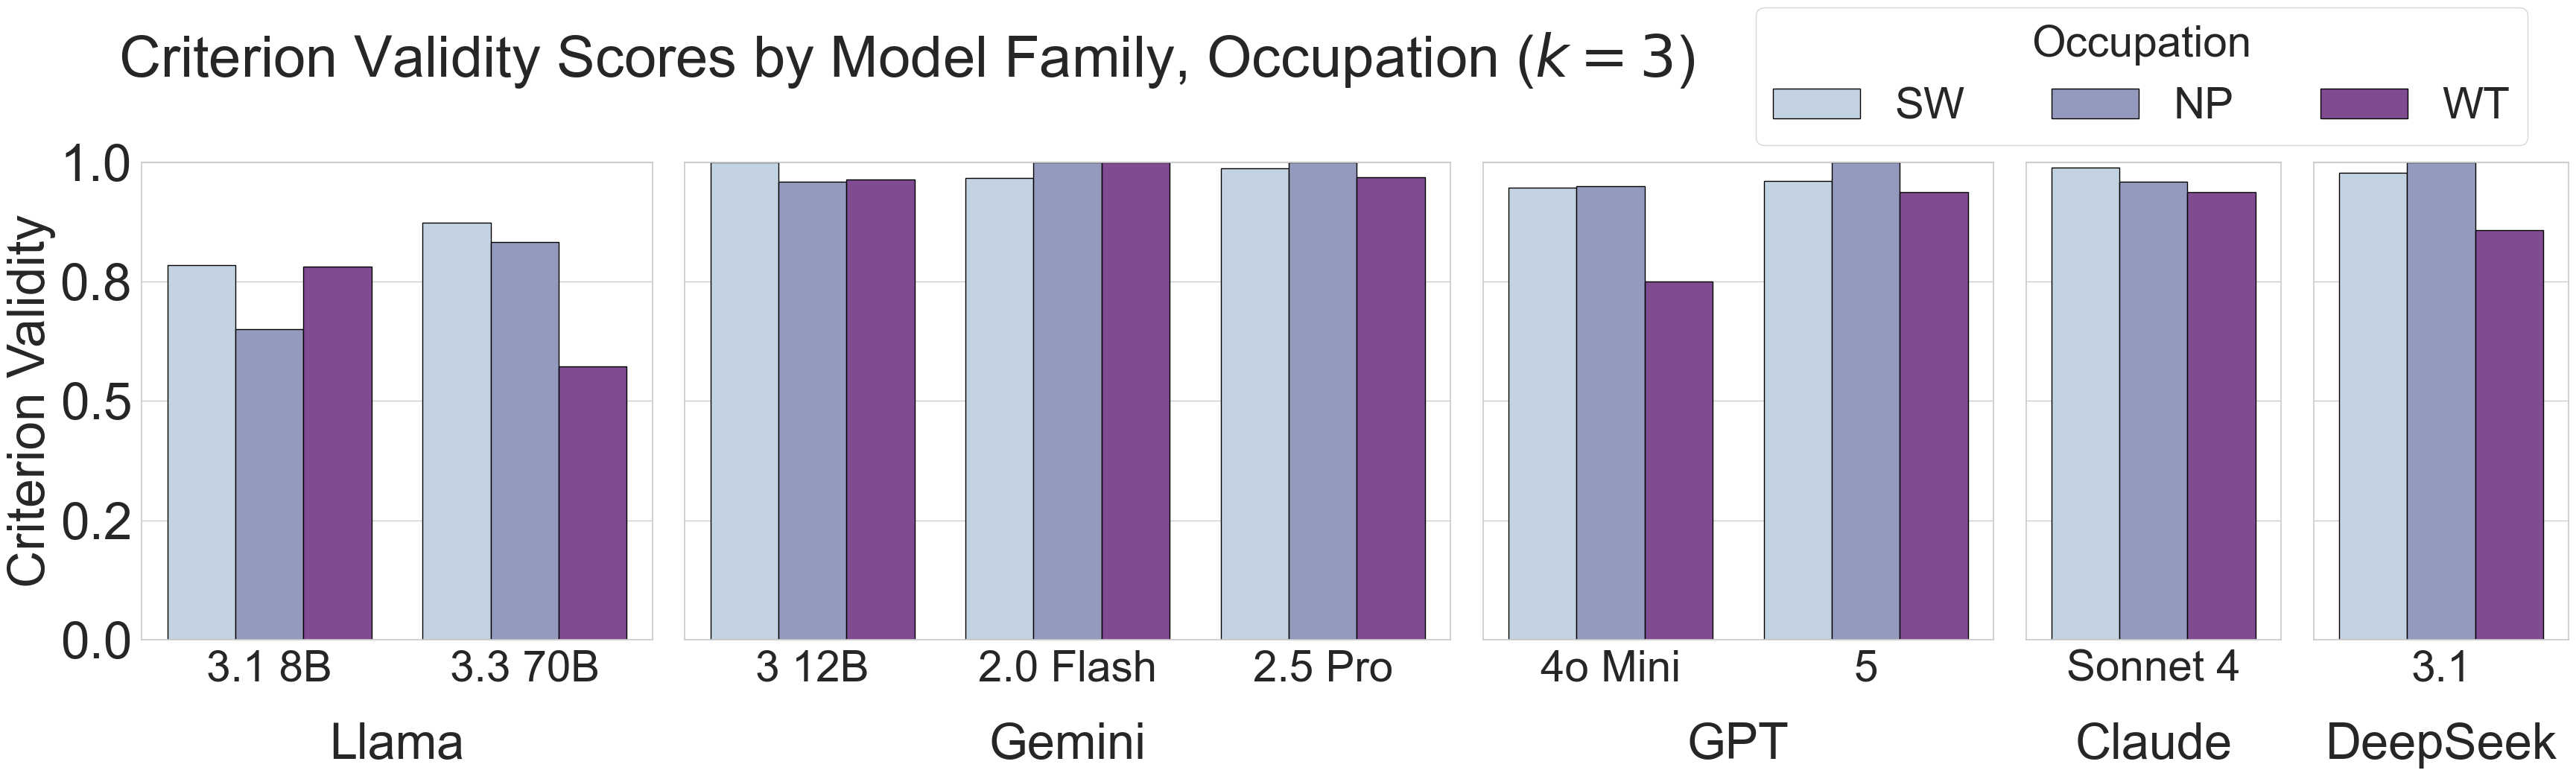

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# --- 1. Data Construction (Focusing only on 'is_correct') ---
# Aggregate each job type individually for 'is_correct' mean
cv_np = (strict_pairs_noncs[strict_pairs_noncs['job_title'] == 'Nurse Practitioner']
         .groupby(['model_id', 'k', 'job_title'])['is_correct'].mean())

cv_swe = (strict_pairs_baseline[strict_pairs_baseline['job_title'] == 'Software Engineer']
          .groupby(['model_id', 'k', 'job_title'])['is_correct'].mean())

cv_wt = (strict_pairs_noncs[strict_pairs_noncs['job_title'] == 'Wind Turbine Technician']
         .groupby(['model_id', 'k', 'job_title'])['is_correct'].mean())

# Combine and reset index to turn those groupby keys into columns
df = pd.concat([cv_np, cv_swe, cv_wt]).reset_index(name='is_correct')

# Filter for k = 3
df = df[df['k'] == 3]

# --- 2. Mappings & Family Logic ---
short_models = {
    'gpt-5': 'GPT-5',
    'claude-sonnet-4': 'Claude Sonnet 4',
    'gemini-2.5-pro': 'Gem. 2.5 Pro',
    'deepseek-chat-v3.1': 'DeepSeek 3.1',
    'llama-3.3-70b-instruct': 'Llama 3.3 70B',
    'gemma-3-12b-it': 'Gem. 3 12B',
    'gemini-2.0-flash-001': 'Gem. 2.0 Flash',
    'llama-3.1-8b-instruct': 'Llama 3.1 8B',
    'gpt-4o-mini': 'GPT-4o Mini'
}

short_occupations = {
    'Software Engineer': 'SW',
    'Nurse Practitioner': 'NP',
    'Wind Turbine Technician': 'WT'
}

df['model_short'] = df['model_id'].map(short_models)
df['job_short'] = df['job_title'].map(short_occupations)

# Define Model Families
df['family'] = 'Other'
df.loc[df['model_short'].str.contains('Gem\.|Gemini|Gemma', na=False), 'family'] = 'Gemini'
df.loc[df['model_short'].str.contains('Llama', na=False), 'family'] = 'Llama'
df.loc[df['model_short'].str.contains('GPT', na=False), 'family'] = 'GPT'
df.loc[df['model_short'].str.contains('Claude', na=False), 'family'] = 'Claude'
df.loc[df['model_short'].str.contains('DeepSeek', na=False), 'family'] = 'DeepSeek'

def get_version(name):
    # Ensure name is string before replacing
    name_str = str(name)
    return (name_str.replace('Llama ', '')
                    .replace('Gem. ', '')
                    .replace('GPT-', '')
                    .replace('Claude ', '')
                    .replace('DeepSeek ', ''))

df['version'] = df['model_short'].apply(get_version)

# --- 3. Plotting Setup ---
families = ['Llama', 'Gemini', 'GPT', 'Claude', 'DeepSeek']
version_order = {
    'Llama': ['3.1 8B', '3.3 70B'],
    'Gemini': ['3 12B', '2.0 Flash', '2.5 Pro'],
    'GPT': ['4o Mini', '5'],
    'Claude': ['Sonnet 4'],
    'DeepSeek': ['3.1']
}
job_order = ['SW', 'NP', 'WT']

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 5, figsize=(35, 12), sharey=True, 
                         gridspec_kw={'width_ratios': [2, 3, 2, 1, 1]})

all_handles, all_labels = [], []

for i, family in enumerate(families):
    ax = axes[i]
    family_data = df[df['family'] == family].copy()
    
    sns.barplot(
        data=family_data, 
        x='version', 
        y='is_correct', 
        hue='job_short', 
        hue_order=job_order,
        order=version_order[family],
        palette='BuPu', 
        ax=ax, 
        edgecolor='black'
    )
    
    # Capture legend handles from the first available subplot
    h, l = ax.get_legend_handles_labels()
    if h and not all_handles:
        all_handles, all_labels = h, l
        
    ax.set_xlabel("")
    ax.set_ylabel("Criterion Validity" if i == 0 else "", fontsize=50)
    ax.tick_params(axis='x', labelsize=42)
    ax.tick_params(axis='y', labelsize=50)
    ax.set_ylim(0, 1)
    
    # Label the model family at the bottom
    ax.text(0.5, -0.25, family, fontsize=48, ha='center', transform=ax.transAxes)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Remove individual legend
    if ax.get_legend():
        ax.get_legend().remove()

# Global Legend
if all_handles:
    fig.legend(all_handles, all_labels, title="Occupation", title_fontsize=42, fontsize=42, 
               loc='upper right', bbox_to_anchor=(0.98, 1), ncol=3)

fig.suptitle("Criterion Validity Scores by Model Family, Occupation ($k=3$)", 
             fontsize=56, y=0.95, x=0.35)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.show()

# Over-Assessment, Dis-Aggregated by Demographic Information Type
Filter by demographics that are unequal, then group by each demographic

In [75]:
def get_over_assessment_s_gender(df):
    unequal = df[df['gender_base'] != df['gender_variant']]

    # condition on fact that gender we focus on is less qualified
    unequal['subject_gender'] = np.where(
        unequal['better'] == 'first',
        unequal['gender_variant'],
        unequal['gender_base']
    )

    # (Picked Variant when Base was better) OR (Picked Base when Variant was better)
    unequal['is_over_assessed'] = np.where(
        (unequal['better'] == 'first') & (unequal['selected_first'] == False), 1,
        np.where(
            (unequal['better'] == 'second') & (unequal['selected_first'] == True), 1, 
            0
        )
    )

    result = (
        unequal
        .groupby(['model_id', 'subject_gender'])['is_over_assessed']
        .mean()
        .reset_index()
    )

    return result

# Example job to focus on:
job = 'Software Engineer'
get_over_assessment_s_gender(strict_pairs_baseline[strict_pairs_baseline['job_title'] == job])

/var/folders/f7/7xl7dp953nx9rbc6r_554dvc0000gn/T/ipykernel_22227/1482741054.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unequal['subject_gender'] = np.where(
/var/folders/f7/7xl7dp953nx9rbc6r_554dvc0000gn/T/ipykernel_22227/1482741054.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  unequal['is_over_assessed'] = np.where(


,model_id,subject_gender,is_over_assessed
0,claude-sonnet-4,M,0.000000
1,claude-sonnet-4,W,0.018868
2,deepseek-chat-v3.1,M,0.068966
3,deepseek-chat-v3.1,W,0.132075
4,gemini-2.0-flash-001,M,0.074074
5,gemini-2.0-flash-001,W,0.087719
6,gemini-2.5-pro,M,0.066667
7,gemini-2.5-pro,W,0.021739
8,gemma-3-12b-it,M,0.016949
9,gemma-3-12b-it,W,0.035714


## Analysis of Equal Pairs

In [7]:
gender_map = {'B_W' : 'Woman', 'B_M' : 'Man', 'W_W' : 'Woman', 'W_M' : 'Man'}
race_map = {'B_W' : 'White', 'B_M' : 'Black', 'W_W' : 'White', 'W_M' : 'Black'}

equal_pairs_baseline['gender_base'] = equal_pairs_baseline['demographic_base'].map(gender_map)
equal_pairs_baseline['gender_variant'] = equal_pairs_baseline['demographic_variant'].map(gender_map)
equal_pairs_baseline['race_base'] = equal_pairs_baseline['demographic_base'].map(race_map)
equal_pairs_baseline['race_variant'] = equal_pairs_baseline['demographic_variant'].map(race_map)

# Discriminant Validity

In [99]:
dv_by_demo = equal_pairs_baseline.groupby(['model_id', 'experiment_type']).agg({'abstained': 'mean'})
dv_by_demo



abstained
model_id               experiment_type                          
claude-sonnet-4        fairness                         0.885590
                       implicit_demographics_fairness   0.897628
                       validity                         0.907781
                       validity_demographics            0.884503
deepseek-chat-v3.1     fairness                         0.933070
                       implicit_demographics_fairness   0.823310
                       validity                         0.932836
                       validity_demographics            0.934351
gemini-2.0-flash-001   fairness                         0.791989
                       implicit_demographics_fairness   0.529210
                       validity                         0.819892
                       validity_demographics            0.795833
gemini-2.5-pro         fairness                         0.968471
                       implicit_demographics_fairness   0.960246
                       validity                         0.969950
                       validity_demographics            0.968966
gemma-3-12b-it         fairness                         0.406150
                       implicit_demographics_fairness   0.149830
                       validity                         0.383580
                       validity_demographics            0.382514
gpt-4o-mini            fairness                         0.804131
                       implicit_demographics_fairness   0.370396
                       validity                         0.872312
                       validity_demographics            0.826147
gpt-5                  fairness                         0.933989
                       implicit_demographics_fairness   0.888639
                       validity                         0.941472
                       validity_demographics            0.929293
llama-3.1-8b-instruct  fairness                         0.162379
                       implicit_demographics_fairness   0.096935
                       validity                         0.166096
                       validity_demographics            0.158416
llama-3.3-70b-instruct fairness                         0.957328
                       implicit_demographics_fairness   0.897241
                       validity                         0.967016
                       validity_demographics            0.960184

   family  version       val       err
0     GPT  4o Mini  0.624817  0.004779
1     GPT        5  0.914781  0.003063
2  Gemini  2.5 Pro  0.965087  0.002011
3  Gemini    3 12B  0.292892  0.004491
4   Llama   3.1 8B  0.134227  0.003714


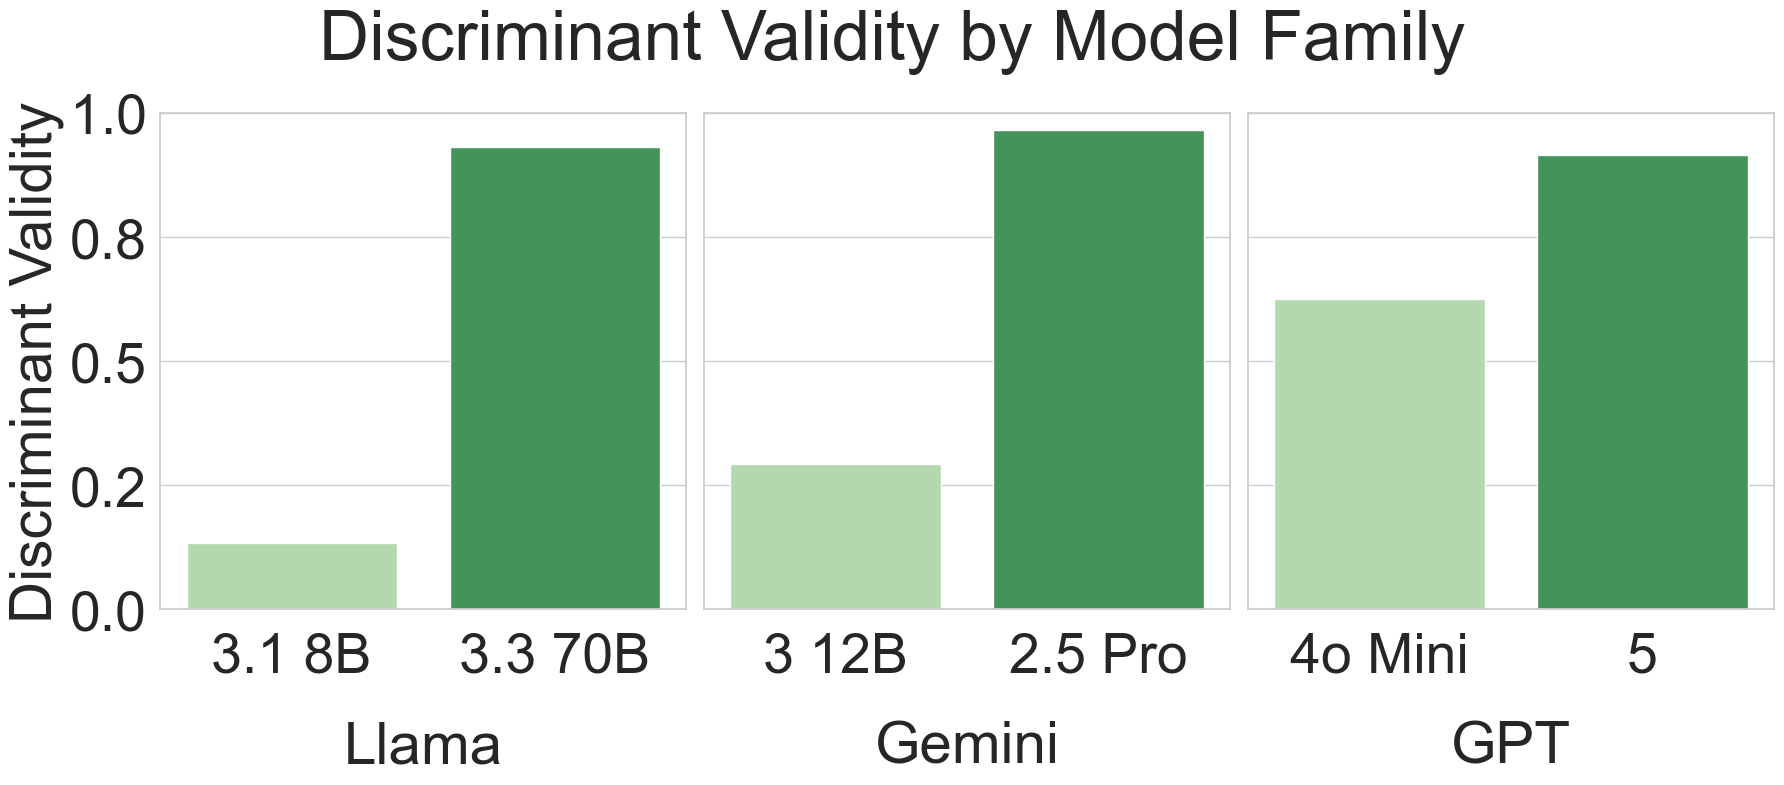

In [259]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Processing and Family Extraction
def process_family_data(df_input):
    df = df_input.copy()
    short_models = {
        'gpt-5': 'GPT-5', 'claude-sonnet-4': 'Claude Sonnet 4',
        'gemini-2.5-pro': 'Gemini 2.5 Pro', 'deepseek-chat-v3.1': 'DeepSeek 3.1',
        'llama-3.3-70b-instruct': 'Llama 3.3 70B', 'gemma-3-12b-it': 'Gemma 3 12B',
        'gemini-2.0-flash-001': 'Gemini 2.0 Flash', 'llama-3.1-8b-instruct': 'Llama 3.1 8B',
        'gpt-4o-mini': 'GPT-4o Mini'
    }
    df['model_name'] = df['model_id'].map(short_models)
    
    # Assign Family
    df['family'] = 'Other'
    df.loc[df['model_name'].str.contains('Gemini|Gemma', na=False), 'family'] = 'Gemini'
    df.loc[df['model_name'].str.contains('Llama', na=False), 'family'] = 'Llama'
    df.loc[df['model_name'].str.contains('GPT', na=False), 'family'] = 'GPT'
    
    # Clean Version Names for X-axis
    df['version'] = (df['model_name'].str.replace('Gemini ', '')
                                    .str.replace('Gemma ', '')
                                    .str.replace('Llama ', '')
                                    .str.replace('GPT-', ''))
    return df

# Apply processing and aggregate (averaging implicit/explicit)
processed_df = process_family_data(equal_pairs_baseline)
processed_df = processed_df[processed_df['model_name'] != 'Gemini 2.0 Flash']

families = ['Llama', 'Gemini', 'GPT']
df_plot = (processed_df[processed_df['family'].isin(families)]
           .groupby(['family', 'version'])['abstained']
           .agg(val='mean', err='sem')
           .reset_index().fillna(0))

print(df_plot.head())

# 2. Hierarchical Plotting with Subfigures
version_order = {
    'Llama': ['3.1 8B', '3.3 70B'],
    'Gemini': ['3 12B', '2.5 Pro'],
    'GPT': ['4o Mini', '5']
}

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 8.5), sharey=True)

for i, family in enumerate(families):
    ax = axes[i]
    family_data = df_plot[df_plot['family'] == family].copy()
    
    # Enforce order
    order = version_order[family]
    family_data['version'] = pd.Categorical(family_data['version'], categories=order, ordered=True)
    family_data = family_data.sort_values('version')
    
    # FIX: Add 'hue_order' so Seaborn only allocates slots for models in THIS family
    sns.barplot(
        data=family_data, 
        x='version', 
        y='val', 
        hue='version', 
        hue_order=order,
        palette='Greens', 
        ax=ax, 
        legend=False
    )
    
    # Formatting
    # ax.set_title(family, fontsize=42, pad=40)
    ax.set_xlabel("")
    ax.set_ylabel("Discriminant Validity" if i == 0 else "", fontsize=42)
    ax.tick_params(axis='x', labelsize=40, pad=10)
    ax.tick_params(axis='y', labelsize=40)
    ax.set_ylim(0, 1)

    ax.text(0.5, -0.31, family, fontsize=42, ha='center', 
            transform=ax.transAxes)

    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
fig.suptitle("Discriminant Validity by Model Family", fontsize=50)

plt.tight_layout()
plt.show()

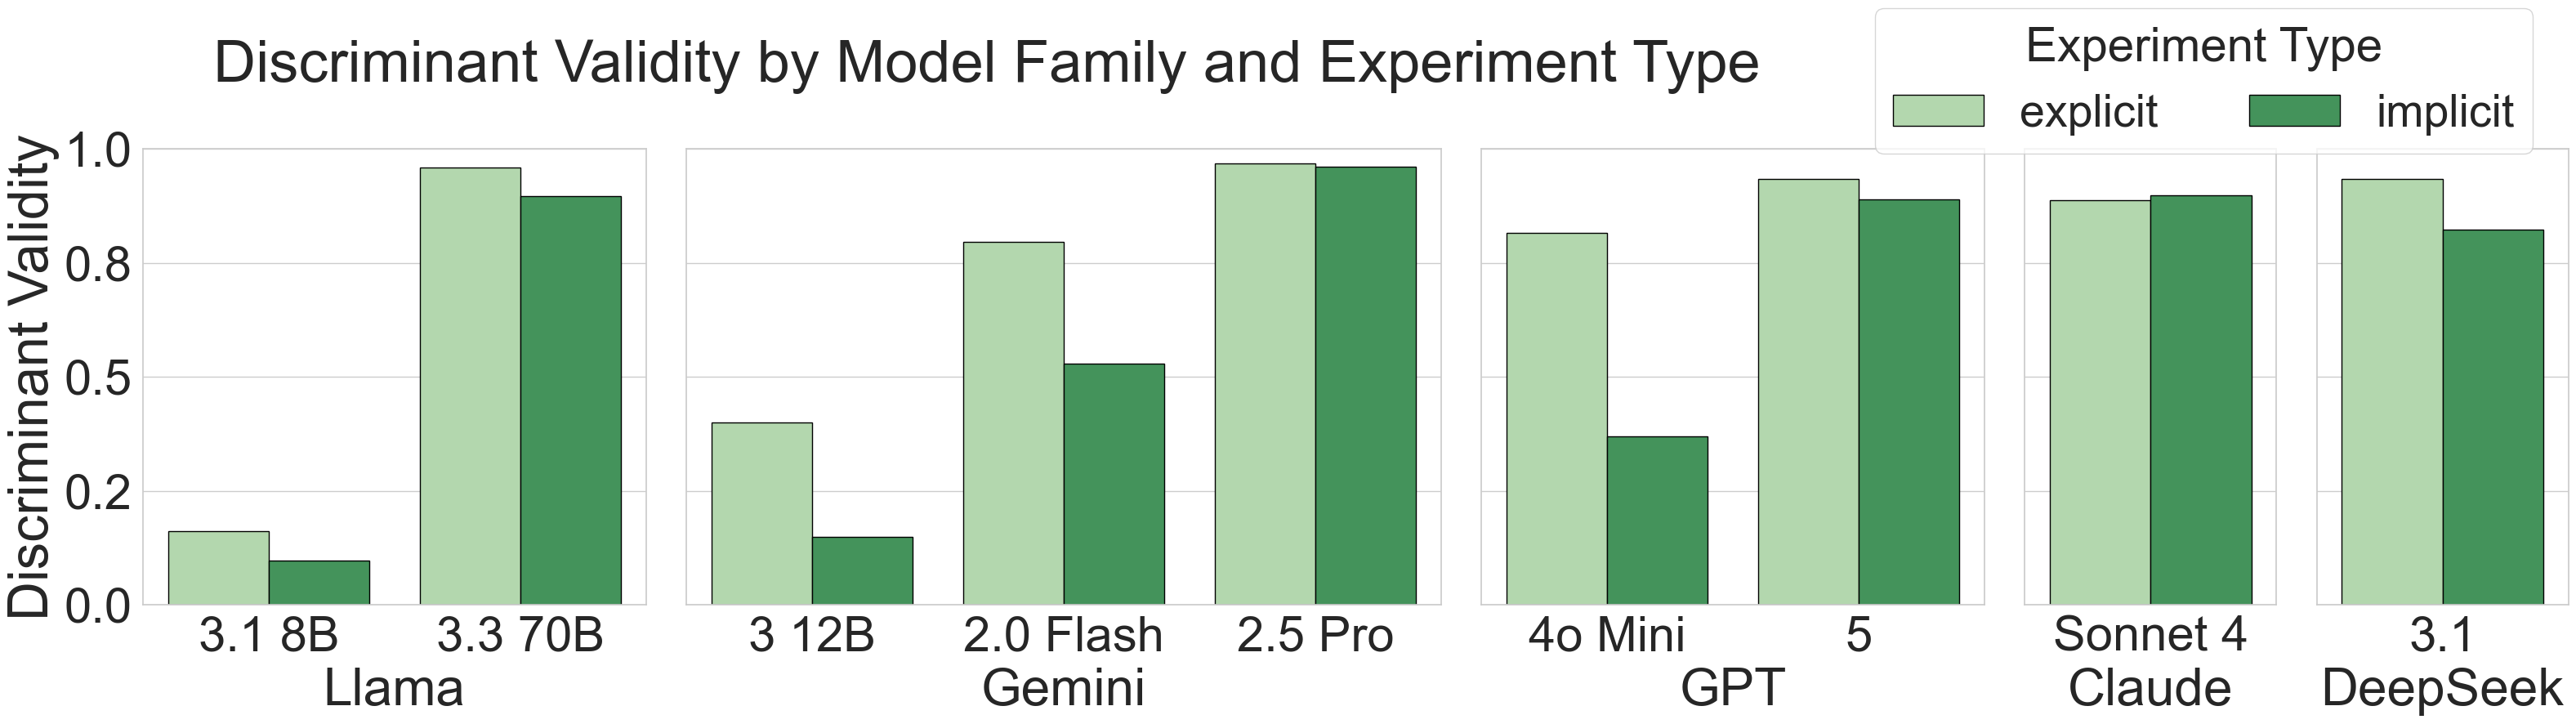

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

def experiment_type(row):
    if 'implicit' in row['experiment_type']: return 'implicit'
    else: return 'explicit'

df = equal_pairs_baseline.copy()
df['experiment_type'] = df.apply(experiment_type, axis=1)

short_models = {
    'gpt-5': 'GPT-5',
    'claude-sonnet-4': 'Claude Sonnet 4',
    'gemini-2.5-pro': 'Gem. 2.5 Pro',
    'deepseek-chat-v3.1': 'DeepSeek 3.1',
    'llama-3.3-70b-instruct': 'Llama 3.3 70B',
    'gemma-3-12b-it': 'Gem. 3 12B',
    'gemini-2.0-flash-001': 'Gem. 2.0 Flash',
    'llama-3.1-8b-instruct': 'Llama 3.1 8B',
    'gpt-4o-mini': 'GPT-4o Mini'
}
df['model_short'] = df['model_id'].map(short_models)

df['family'] = 'Other'
df.loc[df['model_short'].str.contains('Gem\.|Gemini|Gemma', na=False), 'family'] = 'Gemini'
df.loc[df['model_short'].str.contains('Llama', na=False), 'family'] = 'Llama'
df.loc[df['model_short'].str.contains('GPT', na=False), 'family'] = 'GPT'
df.loc[df['model_short'].str.contains('Claude', na=False), 'family'] = 'Claude'
df.loc[df['model_short'].str.contains('DeepSeek', na=False), 'family'] = 'DeepSeek'

# Clean versioning logic to match version_order exactly
def get_version(name):
    return (name.replace('Llama ', '')
                .replace('Gem. ', '')
                .replace('GPT-', '')
                .replace('Claude ', '')
                .replace('DeepSeek ', ''))

df['version'] = df['model_short'].apply(get_version)

families = ['Llama', 'Gemini', 'GPT', 'Claude', 'DeepSeek']
version_order = {
    'Llama': ['3.1 8B', '3.3 70B'],
    'Gemini': ['3 12B', '2.0 Flash', '2.5 Pro'],
    'GPT': ['4o Mini', '5'],
    'Claude': ['Sonnet 4'],
    'DeepSeek': ['3.1']
}

df_plot = (df.groupby(['family', 'version', 'experiment_type'])['abstained']
           .mean()
           .reset_index(name='val'))

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 5, figsize=(32, 9.5), sharey=True, 
                         gridspec_kw={'width_ratios': [2, 3, 2, 1, 1]})

exp_types = ['explicit', 'implicit']
all_handles = []
all_labels = []

for i, family in enumerate(families):
    ax = axes[i]
    family_data = df_plot[df_plot['family'] == family].copy()
    order = version_order[family]
    
    sns.barplot(
        data=family_data, 
        x='version', 
        y='val', 
        hue='experiment_type', 
        hue_order=exp_types,
        order=order,
        palette='Greens', 
        ax=ax, 
        edgecolor='black'
    )
    
    # Collect handles for legend from the first plot that has them
    h, l = ax.get_legend_handles_labels()
    if h and not all_handles:
        all_handles, all_labels = h, l
        
    ax.set_xlabel("")
    ax.set_ylabel("Discriminant Validity" if i == 0 else "", fontsize=48)
    ax.tick_params(axis='x', labelsize=43)
    ax.tick_params(axis='y', labelsize=43)
    ax.set_ylim(0, 1)
    
    ax.text(0.5, -0.22, family, fontsize=46, ha='center', transform=ax.transAxes)
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    leg = ax.get_legend()
    if leg:
        leg.remove()

if all_handles:
    fig.legend(all_handles, all_labels, title="Experiment Type", title_fontsize=42, fontsize=40, 
               loc='upper right', bbox_to_anchor=(0.98, 1), ncol=2)

fig.suptitle("Discriminant Validity by Model Family and Experiment Type", 
             fontsize=52, y=0.93, x=0.38)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Over Assessment

In [79]:
def get_over_assessment_s_demographic(df):
    # filter for diff demographics
    pairs = df[df['demographic_base'] != df['demographic_variant']].copy()

    print(pairs['demographic_base'].unique())

    # if selected_first is True, base won (1). if false, base lost (0).
    base = pairs[['model_id', 'experiment_type', 'demographic_base', 'selected_first']].copy()
    base.columns = ['model_id', 'experiment_type', 'demographic', 'is_selected']
    # Convert boolean to int (True -> 1, False -> 0)
    base['is_over_assessed'] = base['is_selected'].astype(int)

    # if selected_first is False, variant won (1). if true, variant lost (0).
    variant = pairs[['model_id', 'experiment_type', 'demographic_variant', 'selected_second']].copy()
    variant.columns = ['model_id', 'experiment_type', 'demographic', 'is_selected']
    # invert selection (true becomes false, false becomes true) then convert to int
    variant['is_over_assessed'] = (variant['is_selected']).astype(int)

    combined = pd.concat([base, variant], axis=0)

    result = (
        combined
        .groupby(['experiment_type', 'demographic'])['is_over_assessed']
        .mean()
        .reset_index()
    )

    return result

job = 'Software Engineer'
print(job)
print(get_over_assessment_s_demographic(strict_pairs_baseline[strict_pairs_baseline['job_title'] == job]).head(60))


job = 'Nurse Practitioner'
print(job)
print(get_over_assessment_s_demographic(strict_pairs_noncs[strict_pairs_noncs['job_title'] == job]))

(get_over_assessment_s_demographic(strict_pairs_baseline).head(70))

Software Engineer
['B_W' 'W_W' 'B_M' 'W_M']
         experiment_type demographic  is_over_assessed
0  validity_demographics         B_M          0.423025
1  validity_demographics         B_W          0.511754
2  validity_demographics         W_M          0.450680
3  validity_demographics         W_W          0.419598
Nurse Practitioner
['W_M']
         experiment_type demographic  is_over_assessed
0  validity_demographics         W_M               0.5
1  validity_demographics         W_W               0.3
['B_W' 'W_M' 'B_M' 'W_W']


,experiment_type,demographic,is_over_assessed
0,validity_demographics,B_M,0.442301
1,validity_demographics,B_W,0.458231
2,validity_demographics,W_M,0.392548
3,validity_demographics,W_W,0.417257


In [80]:
def get_over_assessment_e_demographic(df):
    # filter for diff demographics
    pairs = df[df['demographic_base'] != df['demographic_variant']].copy()

    # if selected_first is True, base won (1). if false, base lost (0).
    base = pairs[['model_id', 'experiment_type', 'demographic_base', 'selected_first']].copy()
    base.columns = ['model_id', 'experiment_type', 'demographic', 'is_selected']
    # Convert boolean to int (True -> 1, False -> 0)
    base['is_over_assessed'] = base['is_selected'].astype(int)

    # if selected_first is False, variant won (1). if true, variant lost (0).
    variant = pairs[['model_id', 'experiment_type', 'demographic_variant', 'selected_second']].copy()
    variant.columns = ['model_id', 'experiment_type', 'demographic', 'is_selected']
    # invert selection (true becomes false, false becomes true) then convert to int
    variant['is_over_assessed'] = (variant['is_selected']).astype(int)

    combined = pd.concat([base, variant], axis=0)

    result = (
        combined
        .groupby(['experiment_type', 'demographic'])['is_over_assessed']
        .mean()
        .reset_index()
    )

    return result

job = 'Software Engineer'
print(get_over_assessment_e_demographic(equal_pairs_baseline[equal_pairs_baseline['job_title'] == job]).head(60))

(get_over_assessment_e_demographic(equal_pairs_baseline).head(70))

                   experiment_type demographic  is_over_assessed
0                         fairness         B_M          0.085749
1                         fairness         B_W          0.094611
2                         fairness         W_M          0.082734
3                         fairness         W_W          0.096038
4   implicit_demographics_fairness         B_M          0.204250
5   implicit_demographics_fairness         B_W          0.227652
6   implicit_demographics_fairness         W_M          0.112440
7   implicit_demographics_fairness         W_W          0.207944
8            validity_demographics         B_M          0.102113
9            validity_demographics         B_W          0.076555
10           validity_demographics         W_M          0.065385
11           validity_demographics         W_W          0.129231


,experiment_type,demographic,is_over_assessed
0,fairness,B_M,0.112814
1,fairness,B_W,0.122490
2,fairness,W_M,0.104054
3,fairness,W_W,0.114644
4,implicit_demographics_fairness,B_M,0.241607
5,implicit_demographics_fairness,B_W,0.248951
6,implicit_demographics_fairness,W_M,0.138010
7,implicit_demographics_fairness,W_W,0.220983
8,validity_demographics,B_M,0.119954
9,validity_demographics,B_W,0.130766


# Selection Rate by Coarse Gender, Race, Job

Filter out pairs where coarse gender, race are equivalent. 

In [38]:
noncs_baseline_noabstain_equal = pd.read_csv('noncs/baseline_noabstain/equal_pairs.csv')
noncs_baseline_noabstain_strict = pd.read_csv('noncs/baseline_noabstain/strict_preference_pairs.csv')

In [39]:
noncs_baseline_noabstain_equal['job_title'].unique()

jobs_to_include = ['Financial Analyst', 'Nurse Practitioner', 'Software Engineer', 'Wind Turbine Technician', 'Business Development Representative - German Speaking']
noncs_baseline_noabstain_equal = noncs_baseline_noabstain_equal[noncs_baseline_noabstain_equal['job_title'].isin(jobs_to_include)]

In [40]:
bdr = equal_pairs_baseline_noabstain[equal_pairs_baseline_noabstain['job_title'] == 'Business Development Representative - German Speaking']

noncs_baseline_noabstain_equal = pd.concat([noncs_baseline_noabstain_equal, bdr])

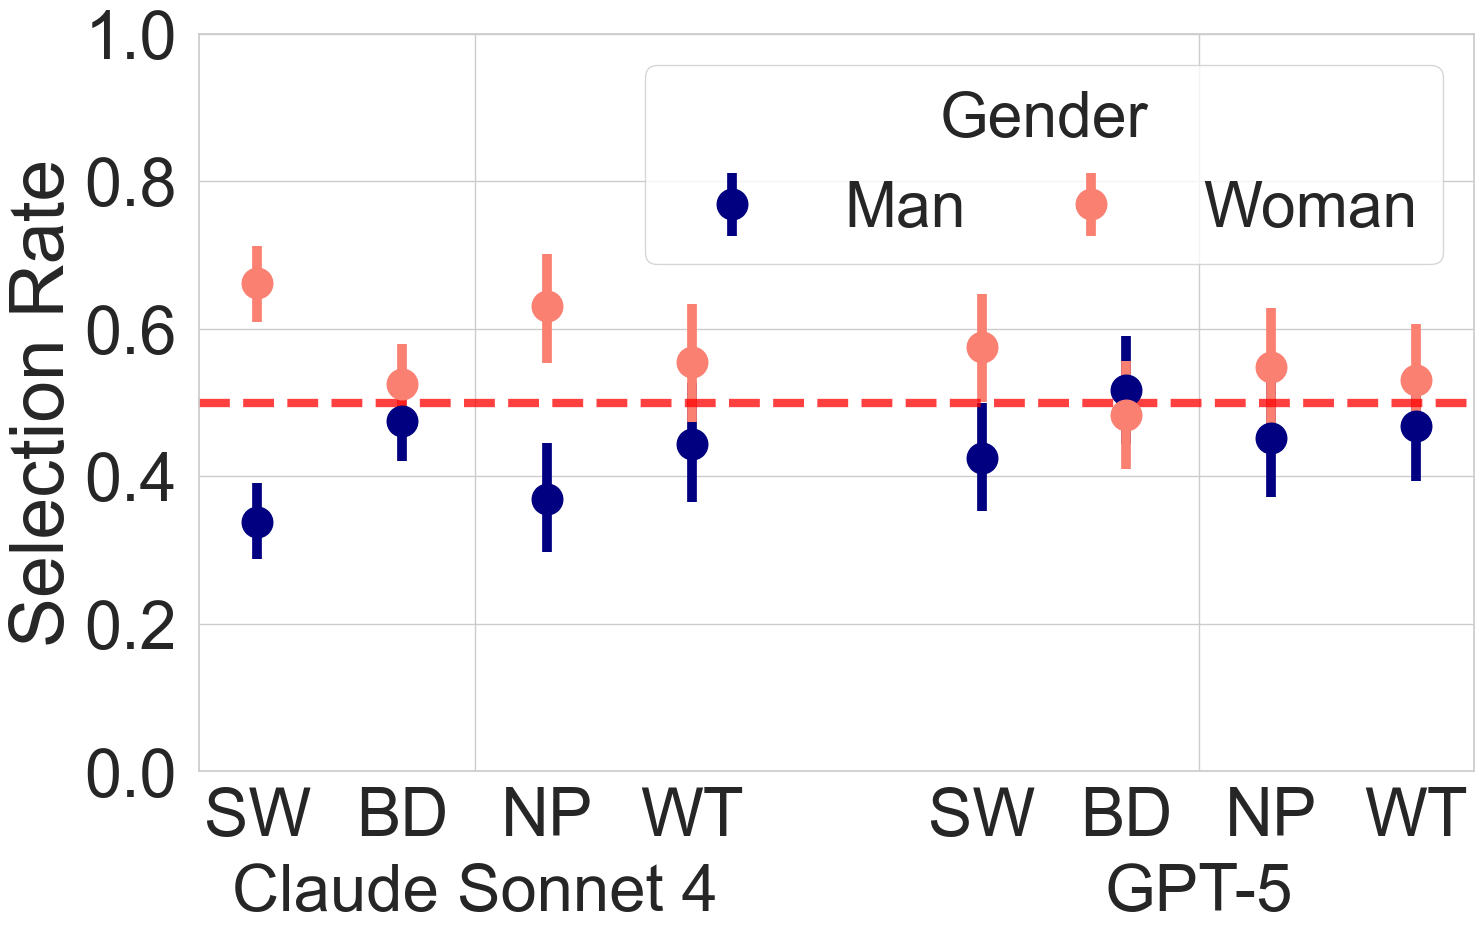

In [90]:
agg = gender_selection_rate.copy()

gender_map = {'M': 'Man', 'W': 'Woman'}
agg['gender'] = agg['gender'].map(gender_map)

job_order = [
    'Software Engineer',
    'Business Development Representative - German Speaking', 
    'Nurse Practitioner',
    'Wind Turbine Technician'
]

short_jobs = {
    'Software Engineer': 'SW',
    'Business Development Representative - German Speaking': 'BD',
    'Nurse Practitioner': 'NP',
    'Wind Turbine Technician': 'WT'
}

short_models = {
    'claude-sonnet-4':'Claude Sonnet 4', 'deepseek-chat-v3.1':'DeepSeek v3.1',
    'gemini-2.0-flash-001':'Gemini 2.0 Flash', 'gemini-2.5-pro':'Gemini 2.5 Pro',
    'gemma-3-12b-it':'Gemma 3 12B', 'gpt-4o-mini':'GPT-4o Mini', 'gpt-5':'GPT-5',
    'llama-3.1-8b-instruct':'Llama 3.1 8B', 'llama-3.3-70b-instruct':'Llama 3.3 70B'
}

top_performers = ['Claude Sonnet 4', 'GPT-5']

agg = agg[agg['job_title'].isin(job_order)]
agg['job_short'] = agg['job_title'].map(short_jobs)
agg['model_short'] = agg['model_id'].map(short_models)
agg = agg[agg['model_short'].isin(top_performers)]

pivot = agg.pivot_table(
    index=['model_short', 'job_short'],
    columns='gender',
    values=['selection_rate', 'ci_low', 'ci_high']
).reset_index()


fig, ax = plt.subplots(figsize=(15, 10))

# ensure sig figs of .X using matplotlib FormatStrFormatter
ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

models = pivot['model_short'].unique()
num_jobs = len(job_order)

for i, model in enumerate(models):
    sub = pivot[pivot['model_short'] == model]
    
    for j, full_job in enumerate(job_order):
        job = short_jobs[full_job]
        row = sub[sub['job_short'] == job]
        if row.empty: 
            continue

        x = i * (num_jobs + 1) + j

        for gender, color in [('Man', 'navy'), ('Woman', 'salmon')]:
            try:
                rate = row[('selection_rate', gender)].values[0]
                low = row[('ci_low', gender)].values[0]
                high = row[('ci_high', gender)].values[0]
                
                ax.errorbar(
                    x, rate,
                    yerr=[[rate - low], [high - rate]],
                    fmt='o',
                    color=color,
                    capsize=0,
                    linewidth=7,
                    markersize=22,
                    label=gender if (i == 0 and j == 0) else None
                )
            except (KeyError, IndexError):
                continue

# baseline
ax.axhline(0.5, linestyle='--', color='red', linewidth=6, alpha=0.75)

tick_positions = [
    i * (num_jobs + 1) + (num_jobs - 1) / 2
    for i in range(len(models))
]
ax.set_xticks(tick_positions)
ax.set_xticklabels(models)

for i, model in enumerate(models):
    for j, full_job in enumerate(job_order):
        job = short_jobs[full_job]
        x = i * (num_jobs + 1) + j
        ax.text(x, -0.02, job,
                ha='center', va='top', fontsize=48,
                transform=ax.get_xaxis_transform())

ax.set_ylabel("Selection Rate", fontsize=54)
# ax.set_title("Selection Rates by Model, Job, and Gender", fontsize=57, pad=40)
# ax.tick_params(axis='both', labelsize=38, pad=35)
ax.tick_params(axis='x', labelsize=47, pad=60)
ax.tick_params(axis='y', labelsize=48, pad=10)
ax.legend(title="Gender", fontsize=45, title_fontsize=45, loc='upper right', ncol=2, columnspacing=1.0)
ax.set_ylim(0, 1)

plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.show()

In [53]:
def selection_rate_race(df):
    df_filtered = df[df['race_base'] != df['race_variant']].copy()

    df_filtered['selected_race'] = np.where(
        df_filtered['selected_first'],
        df_filtered['race_base'],
        df_filtered['race_variant']
    )

    agg_rows = []
    grouped = df_filtered.groupby(['model_id', 'job_title'])

    for (model, job), group in grouped:
        n = len(group)
        if n == 0: continue

        for race in ['B', 'W']:
            k = (group['selected_race'] == race).sum()
            
            rate = k / n
            ci_low, ci_high = proportion_confint(k, n, method='wilson')
            
            agg_rows.append({
                'model_id': model,
                'job_title': job,
                'race': race,
                'selection_rate': rate,
                'ci_low': ci_low,
                'ci_high': ci_high,
                'n': n
            })

    return pd.DataFrame(agg_rows)

race_selection_rate = selection_rate_race(noncs_baseline_noabstain_equal)
race_selection_rate

,model_id,job_title,race,selection_rate,ci_low,ci_high,n
0,claude-sonnet-4,Business Development Representative - German S...,B,0.562500,0.507724,0.615793,320
1,claude-sonnet-4,Business Development Representative - German S...,W,0.437500,0.384207,0.492276,320
2,claude-sonnet-4,Financial Analyst,B,0.520833,0.422038,0.618026,96
3,claude-sonnet-4,Financial Analyst,W,0.479167,0.381974,0.577962,96
4,claude-sonnet-4,Nurse Practitioner,B,0.556250,0.478845,0.631017,160
...,...,...,...,...,...,...,...
85,llama-3.3-70b-instruct,Nurse Practitioner,W,0.487500,0.411256,0.564330,160
86,llama-3.3-70b-instruct,Software Engineer,B,0.517123,0.459958,0.573844,292
87,llama-3.3-70b-instruct,Software Engineer,W,0.482877,0.426156,0.540042,292
88,llama-3.3-70b-instruct,Wind Turbine Technician,B,0.513889,0.432961,0.594095,144


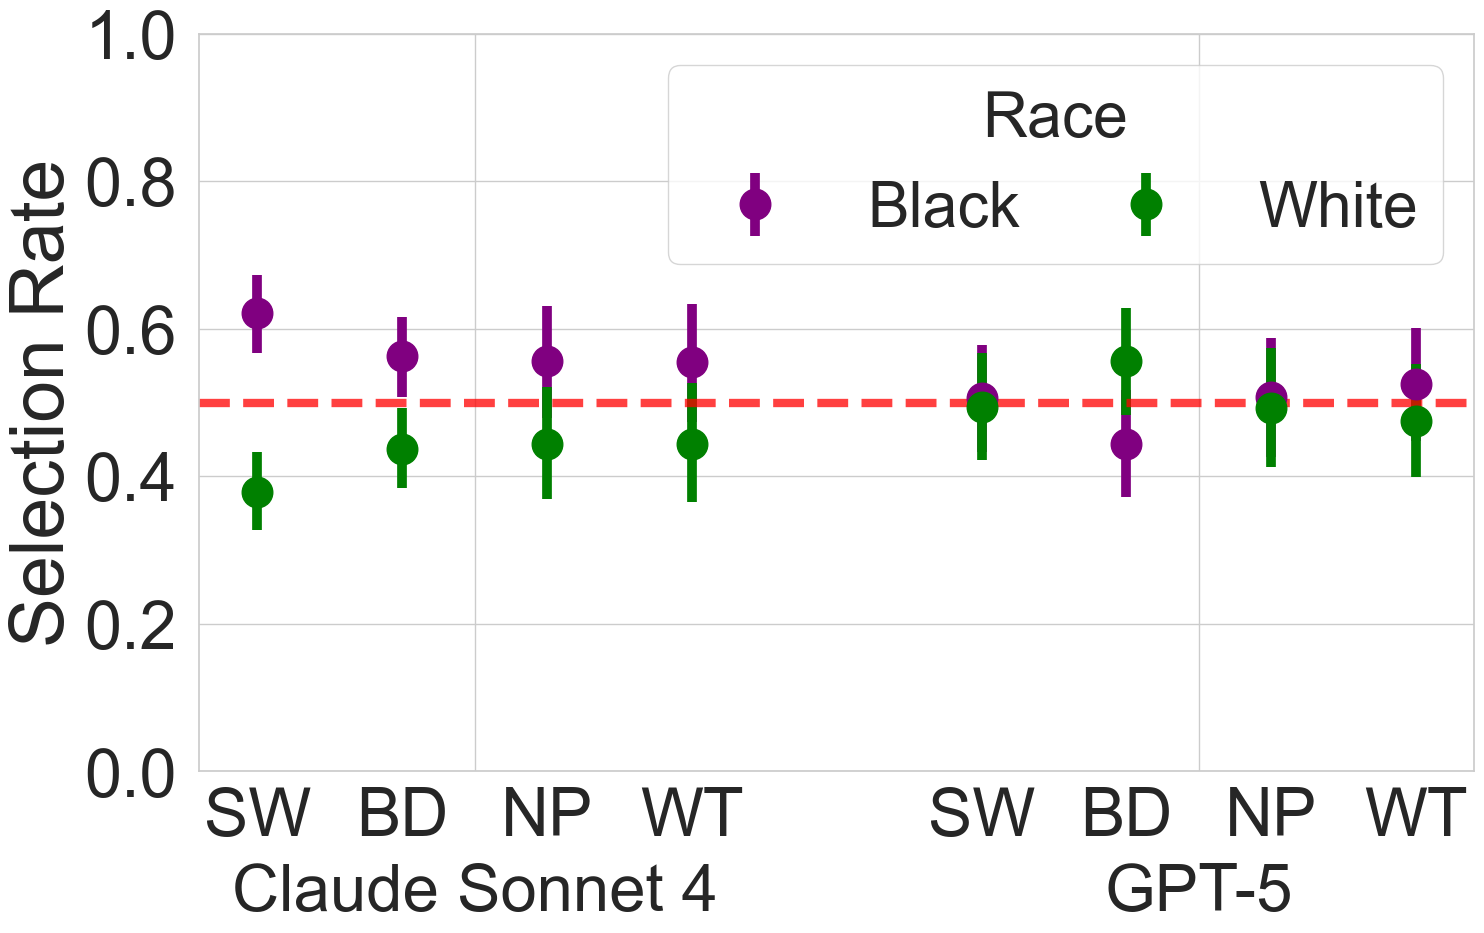

In [91]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Data processing
agg = race_selection_rate.copy()

race_map = {'B': 'Black', 'W': 'White'}
agg['race'] = agg['race'].map(race_map)

job_order = [
    'Software Engineer',
    'Business Development Representative - German Speaking', 
    'Nurse Practitioner',
    'Wind Turbine Technician'
]

short_jobs = {
    'Software Engineer': 'SW',
    'Business Development Representative - German Speaking': 'BD',
    'Nurse Practitioner': 'NP',
    'Wind Turbine Technician': 'WT'
}

# Matching the long-form naming convention from your gender chart
short_models = {
    'claude-sonnet-4':'Claude Sonnet 4', 'deepseek-chat-v3.1':'DeepSeek v3.1',
    'gemini-2.0-flash-001':'Gemini 2.0 Flash', 'gemini-2.5-pro':'Gemini 2.5 Pro',
    'gemma-3-12b-it':'Gemma 3 12B', 'gpt-4o-mini':'GPT-4o Mini', 'gpt-5':'GPT-5',
    'llama-3.1-8b-instruct':'Llama 3.1 8B', 'llama-3.3-70b-instruct':'Llama 3.3 70B'
}

top_performers = ['Claude Sonnet 4', 'GPT-5']

agg = agg[agg['job_title'].isin(job_order)]
agg['job_short'] = agg['job_title'].map(short_jobs)
agg['model_short'] = agg['model_id'].map(short_models)
agg = agg[agg['model_short'].isin(top_performers)]

pivot = agg.pivot_table(
    index=['model_short', 'job_short'],
    columns='race',
    values=['selection_rate', 'ci_low', 'ci_high']
).reset_index()

# Figure initialization
fig, ax = plt.subplots(figsize=(15, 10))

ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

models = pivot['model_short'].unique()
num_jobs = len(job_order)

for i, model in enumerate(models):
    sub = pivot[pivot['model_short'] == model]
    
    for j, full_job in enumerate(job_order):
        job = short_jobs[full_job]
        row = sub[sub['job_short'] == job]
        if row.empty: 
            continue

        x = i * (num_jobs + 1) + j

        # Updated colors for Race analysis
        for race, color in [('Black', 'purple'), ('White', 'green')]:
            try:
                rate = row[('selection_rate', race)].values[0]
                low = row[('ci_low', race)].values[0]
                high = row[('ci_high', race)].values[0]
                
                ax.errorbar(
                    x, rate,
                    yerr=[[rate - low], [high - rate]],
                    fmt='o',
                    color=color,
                    capsize=0,
                    linewidth=7,      # Increased to match gender chart
                    markersize=22,     # Increased to match gender chart
                    label=race if (i == 0 and j == 0) else None
                )
            except (KeyError, IndexError):
                continue

# Baseline at 0.5
ax.axhline(0.5, linestyle='--', color='red', linewidth=6, alpha=0.75)

# Formatting X-axis ticks (Model Names)
tick_positions = [
    i * (num_jobs + 1) + (num_jobs - 1) / 2
    for i in range(len(models))
]
ax.set_xticks(tick_positions)
ax.set_xticklabels(models)

# Job label placement (SWE, BD, etc.)
for i, model in enumerate(models):
    for j, full_job in enumerate(job_order):
        job = short_jobs[full_job]
        x = i * (num_jobs + 1) + j
        ax.text(x, -0.02, job,
                ha='center', va='top', fontsize=48,
                transform=ax.get_xaxis_transform())

ax.set_ylabel("Selection Rate", fontsize=54)
# ax.set_title("Selection Rates by Model, Job, and Gender", fontsize=57, pad=40)
# ax.tick_params(axis='both', labelsize=38, pad=35)
ax.tick_params(axis='x', labelsize=47, pad=60)
ax.tick_params(axis='y', labelsize=48, pad=10)
ax.legend(title="Race", fontsize=45, title_fontsize=45, loc='upper right', ncol=2, columnspacing=1.0)
ax.set_ylim(0, 1)

plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.show()


In [42]:
# Selection rate with abstention, by specific demographic group

def selection_rate_gender(df, jobs_to_include=None):
    # filter valid comparisons
    df_filtered = df[df['gender_base'] != df['gender_variant']].copy()

    # possible outcomes
    conditions = [
        df_filtered['selected_first'] == True,
        df_filtered['selected_second'] == True,
        df_filtered['abstained'] == True
    ]
    
    choices = [
        df_filtered['gender_base'],    # Winner is Base Gender
        df_filtered['gender_variant'], # Winner is Variant Gender
        'Abstained'                    # No Winner
    ]
    
    df_filtered['selection_outcome'] = np.select(conditions, choices, default='Abstained')

    if jobs_to_include:
        df_filtered = df_filtered[df_filtered['job_title'].isin(jobs_to_include)]
    
    grouped = df_filtered.groupby(['model_id', 'job_title'])
    
    # value_counts(normalize=True) will now give % Man, % Woman, and % Abstained
    rates = (
        grouped['selection_outcome']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )
    
    counts = grouped.size().rename('n')
    result = rates.join(counts)

    return result


jobs_to_include = ['Software Engineer', 'Business Development Representative - German Speaking', 'Nurse Practitioner', 'Wind Turbine Technician']

equal_pairs_noncs_jobs = equal_pairs_noncs[equal_pairs_noncs['job_title'].isin(jobs_to_include)]
equal_pairs_baseline_jobs = pd.concat([equal_pairs_baseline, equal_pairs_noncs_jobs])

df_results = selection_rate_gender(equal_pairs_baseline_jobs, jobs_to_include=jobs_to_include)

print(df_results)

                                                                           Abstained  \
model_id               job_title                                                       
claude-sonnet-4        Business Development Representative - German Sp...   0.796053   
                       Nurse Practitioner                                   0.969880   
                       Software Engineer                                    0.950331   
                       Wind Turbine Technician                              0.893258   
deepseek-chat-v3.1     Business Development Representative - German Sp...   0.840000   
                       Nurse Practitioner                                   0.940000   
                       Software Engineer                                    0.869416   
                       Wind Turbine Technician                              0.893750   
gemini-2.0-flash-001   Business Development Representative - German Sp...   0.552147   
                       Nurse Pra